## 1. Setup and load data


In [ ]:
from pathlib import Path
from collections import Counter
import re, json, math, zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from scipy.stats import chi2_contingency, fisher_exact
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

OUTDIR = Path("ecg_xai_scientific_outputs")
FIGDIR = OUTDIR / "figures"
OUTDIR.mkdir(exist_ok=True)
FIGDIR.mkdir(exist_ok=True)

def load_master():
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise ValueError("No file uploaded.")
        filename = next(iter(uploaded))
        path = Path(filename)
    except ImportError:
        candidates = [
            Path("/mnt/data/ECG_XAI_FINAL_VERIFIED_232.xlsx"),
            Path("ECG_XAI_FINAL_VERIFIED_232.xlsx"),
        ]
        path = next((p for p in candidates if p.exists()), None)
        if path is None:
            raise FileNotFoundError("Upload ECG_XAI_FINAL_VERIFIED_232.xlsx")

    if path.suffix.lower() in [".xlsx", ".xls"]:
        xls = pd.ExcelFile(path)
        sheet = "Master_232" if "Master_232" in xls.sheet_names else xls.sheet_names[0]
        df = pd.read_excel(path, sheet_name=sheet, dtype=str).fillna("")
        source = f"{path.name} [{sheet}]"
    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path, dtype=str).fillna("")
        source = path.name
    else:
        raise ValueError("Upload an .xlsx, .xls, or .csv file.")

    return df, source

data, SOURCE = load_master()

print("Loaded:", SOURCE)
print("Master records:", len(data))
print("Columns:", data.shape[1])

if len(data) != 232:
    print(f"WARNING: expected 232 master records; found {len(data)}.")

display(data.head(3))


Saving ECG_XAI_FINAL_VERIFIED_232.xlsx to ECG_XAI_FINAL_VERIFIED_232.xlsx
Loaded: ECG_XAI_FINAL_VERIFIED_232.xlsx [Master_232]
Master records: 232
Columns: 30


,Row,Study_ID,Title,Year,Journal,Authors,DOI,Original_URL,Original_Study_Type,Primary_Study,Focused_Eligibility,Refined_Exclusion_Reason,Model,DL_Architecture_Family,Dataset,XAI_Method,XAI_Evaluation_Category,Clinician_XAI_Validation,Expert_Type,Expert_Count,Clinician_Validation_Evidence,Physiological_Validation,External_Validation,Prospective_Validation,Clinician_in_Loop,Real_World_Deployment,Clinical_Utility_Assessed,Performance_Metrics_Raw,Verification_Level,Verification_Source
0,1,rayyan-534061013,Explainable AI decision model for ECG data of cardiac disorders,2022,Biomedical Signal Processing and Control,"Anand, Atul and Kadian, Tushar and Shetty, Manu Kumar and Gupta, Anubha",,https://www.sciencedirect.com/science/article/pii/S1746809422001069,Experimental,Yes,Include,,ST-CNN-GAP-5 (CNN-based deep learning model with residual connections),CNN,PTB-XL dataset; Arrhythmia dataset,SHAP,,No,,,"Salih et al. supplementary full-text synthesis classifies XAI evaluation as None, not expert-grounded.",Unclear,Unclear,Unclear,Unclear,Unclear,Unclear,"AUC: 93.41% (PTB-XL); Accuracy: 95.8%, AUC: 99.46% (Arrhythmia dataset); F1-score: 79.28%",Secondary systematic-review full-text synthesis,https://link.springer.com/article/10.1007/s10462-024-10852-w
1,2,rayyan-534061014,Interpretable hybrid multichannel deep learning model for heart disease classification using 12-lead ECG signal,2024,IEEE Access,"Ayano, Yehualashet Megersa and Schwenker, Friedhelm and Dufera, Bisrat Derebssa and Debelee, Taye Girma and Ejegu, Yitagesu Getachew",,https://ieeexplore.ieee.org/document/10579752/,Experimental,Yes,Include,,Hybrid CNN-BiLSTM with attention and 2D CNN,CNN,"PTB-XL, CODE-15%, Chapman Arrhythmia",SHAP; Grad-CAM; Attention; CAM,Qualitative visualization,No,,,"Full text shows SHAP and Grad-CAM++ visual interpretation on three ECG datasets, but no clinician rating/comparison of explanations was identified.",Unclear,Multiple datasets; not counted as independent external validation unless train-on-one/test-on-another is explicit,Unclear,Unclear,Unclear,Unclear,Accuracy: 89.84% (PTB-XL); 97.82% (CODE-15%); 98.55%; 98.80% (Chapman),Primary full text,https://doi.org/10.1109/ACCESS.2024.3421641
2,3,rayyan-534061015,Advancing cardiac diagnostics: Exceptional accuracy in abnormal ECG signal classification with cascading deep learning and explainability analysis,2024,Applied Soft Computing,"Zeng, Wei and Shan, Liangmin and Yuan, Chengzhi and Du, Shaoyi",,https://www.sciencedirect.com/science/article/pii/S1568494624008305,Experimental,Yes,Include,,Cascading Deep Learning Model (CNN-based architecture),CNN,ECG dataset,SHAP; Grad-CAM; CAM,Unclear,Unclear,,,No defensible clinician-XAI decision available from the current evidence set; retain as Unclear rather than inventing No.,Unclear,Unclear,Unclear,Unclear,Unclear,Unclear,Accuracy: up to 100%,Needs primary full-text verification,https://www.sciencedirect.com/science/article/pii/S1568494624008305


## 2. Define the focused analysis population




In [ ]:
required = [
    "Title", "Year", "Focused_Eligibility", "DL_Architecture_Family",
    "Dataset", "XAI_Method", "XAI_Evaluation_Category",
    "Clinician_XAI_Validation", "Physiological_Validation",
    "External_Validation", "Prospective_Validation",
    "Clinician_in_Loop", "Real_World_Deployment",
    "Clinical_Utility_Assessed", "Performance_Metrics_Raw"
]

missing = [c for c in required if c not in data.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

eligibility_counts = (
    data["Focused_Eligibility"]
    .replace("", "Unclear")
    .value_counts()
    .rename_axis("Focused_Eligibility")
    .reset_index(name="n")
)

focused = data[data["Focused_Eligibility"].eq("Include")].copy().reset_index(drop=True)
FOCUSED_N = len(focused)

print("Master records:", len(data))
display(eligibility_counts)
print("Focused included studies for primary synthesis:", FOCUSED_N)


Master records: 232


,Focused_Eligibility,n
0,Needs adjudication,126
1,Include,67
2,Exclude,39


Focused included studies for primary synthesis: 67


In [ ]:
def save_table(df, name):
    path = OUTDIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

def clean_status(series):
    s = series.fillna("").astype(str).str.strip()
    s = s.replace("", "Unclear")
    s = s.replace({
        "YES":"Yes", "yes":"Yes",
        "NO":"No", "no":"No",
        "UNCLEAR":"Unclear", "unclear":"Unclear"
    })
    return s

def split_multivalue(series):
    result = []
    for value in series.fillna("").astype(str):
        vals = [x.strip() for x in value.split(";") if x.strip()]
        if "CAM" in vals and any(x in vals for x in ["Grad-CAM", "Grad-CAM++"]):
            vals = [x for x in vals if x != "CAM"]
        result.append(list(dict.fromkeys(vals)))
    return result

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k/n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n))/denom
    half = z*math.sqrt((p*(1-p)/n) + z*z/(4*n*n))/denom
    return center-half, center+half


# Domain A — Description of the evidence base

## 3. Publication


Saved: ecg_xai_scientific_outputs/01_publication_year.csv


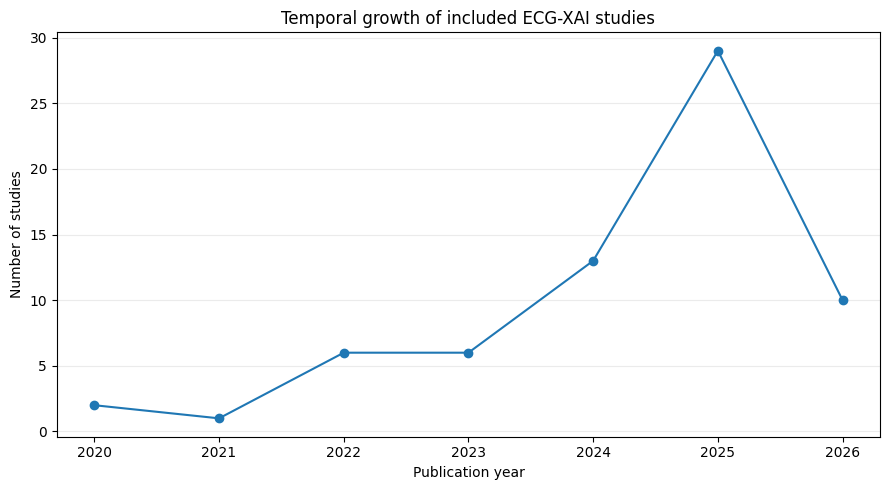

,Year_num,n,percent
0,2020,2,3.0
1,2021,1,1.5
2,2022,6,9.0
3,2023,6,9.0
4,2024,13,19.4
5,2025,29,43.3
6,2026,10,14.9


In [ ]:
focused["Year_num"] = pd.to_numeric(focused["Year"], errors="coerce")

year_counts = (
    focused.dropna(subset=["Year_num"])
    .groupby("Year_num")
    .size()
    .reset_index(name="n")
    .sort_values("Year_num")
)
year_counts["Year_num"] = year_counts["Year_num"].astype(int)
year_counts["percent"] = (year_counts["n"]/FOCUSED_N*100).round(1)

save_table(year_counts, "01_publication_year")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(year_counts["Year_num"], year_counts["n"], marker="o")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of studies")
ax.set_title("Growth of included ECG-XAI studies")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR/"01_publication_year_line.png", dpi=300, bbox_inches="tight")
plt.show()

display(year_counts)


## 4. XAI methods

This is a **multi-response analysis**: a study can use more than one XAI method. A dot plot is used rather than another bar chart.


Saved: ecg_xai_scientific_outputs/02_xai_method_counts.csv


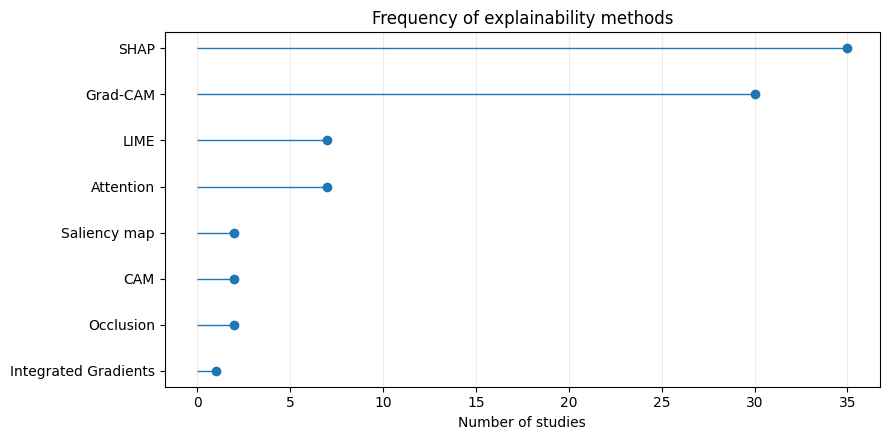

,XAI_method,n,percent_of_studies
0,SHAP,35,52.2
1,Grad-CAM,30,44.8
2,Attention,7,10.4
3,LIME,7,10.4
4,CAM,2,3.0
5,Saliency map,2,3.0
6,Occlusion,2,3.0
7,Integrated Gradients,1,1.5


Note: percentages can exceed 100% in total because XAI methods are multi-response.


In [ ]:
xai_lists = split_multivalue(focused["XAI_Method"])
xai_counter = Counter(x for vals in xai_lists for x in vals)

xai_counts = pd.DataFrame(xai_counter.most_common(), columns=["XAI_method","n"])
xai_counts["percent_of_studies"] = (xai_counts["n"]/FOCUSED_N*100).round(1)
save_table(xai_counts, "02_xai_method_counts")

plot_df = xai_counts.sort_values("n")
fig, ax = plt.subplots(figsize=(9, max(4.5, .48*len(plot_df))))
ax.hlines(y=plot_df["XAI_method"], xmin=0, xmax=plot_df["n"], linewidth=1)
ax.plot(plot_df["n"], plot_df["XAI_method"], "o")
ax.set_xlabel("Number of studies")
ax.set_ylabel("")
ax.set_title("Frequency of explainability methods")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR/"02_xai_methods_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

display(xai_counts)
print("Note: percentages can exceed 100% in total because XAI methods are multi-response.")


## 5. Deep-learning architecture distribution

Architecture is categorical; a dot plot provides a compact scientific frequency display.


Saved: ecg_xai_scientific_outputs/03_architecture_counts.csv


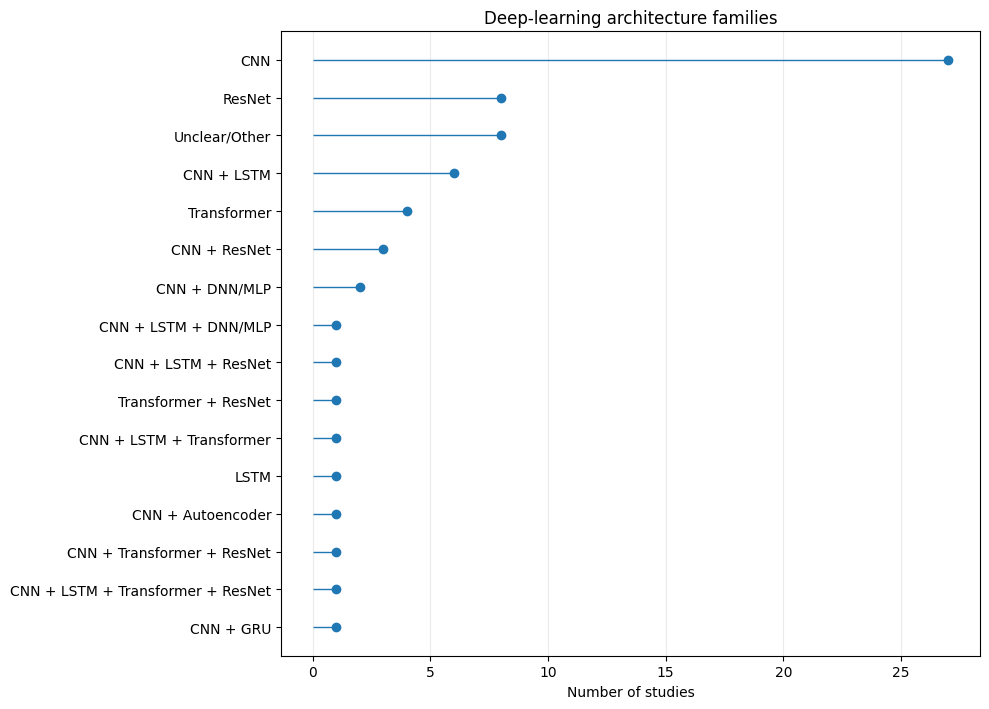

,architecture,n,percent_of_studies
0,CNN,27,40.3
1,Unclear/Other,8,11.9
2,ResNet,8,11.9
3,CNN + LSTM,6,9.0
4,Transformer,4,6.0
5,CNN + ResNet,3,4.5
6,CNN + DNN/MLP,2,3.0
7,CNN + GRU,1,1.5
8,CNN + LSTM + ResNet,1,1.5
9,Transformer + ResNet,1,1.5


In [ ]:
arch_counts = (
    focused["DL_Architecture_Family"]
    .replace("", "Unclear/Other")
    .value_counts()
    .rename_axis("architecture")
    .reset_index(name="n")
)
arch_counts["percent_of_studies"] = (arch_counts["n"]/FOCUSED_N*100).round(1)
save_table(arch_counts, "03_architecture_counts")

plot_df = arch_counts.sort_values("n")
fig, ax = plt.subplots(figsize=(10, max(5, .45*len(plot_df))))
ax.hlines(plot_df["architecture"], 0, plot_df["n"], linewidth=1)
ax.plot(plot_df["n"], plot_df["architecture"], "o")
ax.set_xlabel("Number of studies")
ax.set_ylabel("")
ax.set_title("Deep-learning architecture families")
ax.grid(axis="x", alpha=.25)
plt.tight_layout()
plt.savefig(FIGDIR/"03_architecture_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

display(arch_counts)


# Domain B — Explainability evaluation

## 6. Evaluation strategy

The table is primary. A dot plot is secondary. Importantly, `Unclear` is retained as a reporting category rather than interpreted as absence.


Saved: ecg_xai_scientific_outputs/04_xai_evaluation_categories.csv


,evaluation_category,n,percent
0,Unclear,26,38.8
1,Grad-CAM qualitative,5,7.5
2,Qualitative Grad-CAM,3,4.5
3,Saliency/qualitative,2,3.0
4,Qualitative/literature-grounded,2,3.0
5,Physiological/literature-grounded,2,3.0
6,Qualitative explainability,2,3.0
7,Expert-grounded,2,3.0
8,Technical/qualitative,2,3.0
9,SHAP feature attribution,2,3.0


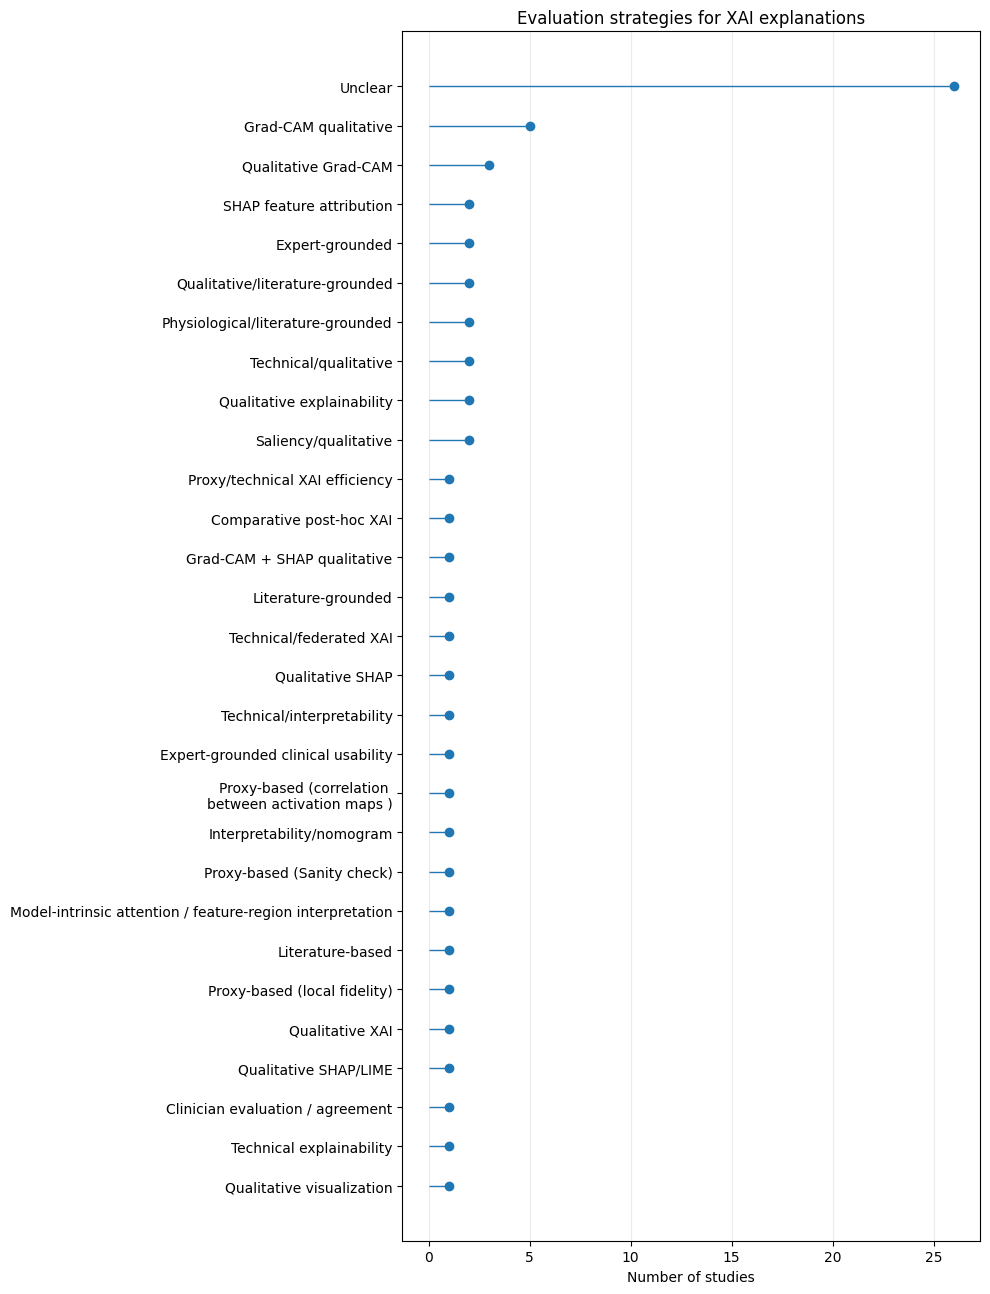

In [ ]:
eval_s = focused["XAI_Evaluation_Category"].replace("", "Unclear").astype(str).str.strip()
eval_counts = eval_s.value_counts().rename_axis("evaluation_category").reset_index(name="n")
eval_counts["percent"] = (eval_counts["n"]/FOCUSED_N*100).round(1)
save_table(eval_counts, "04_xai_evaluation_categories")

display(eval_counts)

plot_df = eval_counts.sort_values("n")
fig, ax = plt.subplots(figsize=(10, max(5, .45*len(plot_df))))
ax.hlines(plot_df["evaluation_category"], 0, plot_df["n"], linewidth=1)
ax.plot(plot_df["n"], plot_df["evaluation_category"], "o")
ax.set_xlabel("Number of studies")
ax.set_ylabel("")
ax.set_title("Evaluation strategies for XAI explanations")
ax.grid(axis="x", alpha=.25)
plt.tight_layout()
plt.savefig(FIGDIR/"04_xai_evaluation_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()


# Domain C — Clinical validation and translation

## 7. Clinician validation of XAI explanations

This is a primary outcome. Report **Yes / No / Unclear** using the full focused denominator. A 100% stacked bar is used because these categories partition the analysis population.


Saved: ecg_xai_scientific_outputs/05_clinician_validation.csv


,status,n,percent
0,Yes,4,6.0
1,No,41,61.2
2,Unclear,22,32.8


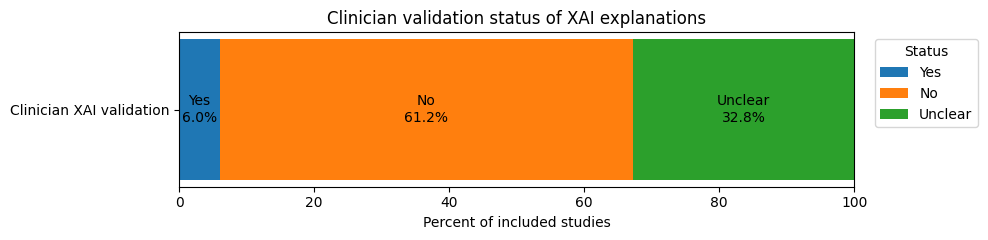

Saved: ecg_xai_scientific_outputs/05b_clinician_validation_denominators.csv


,denominator,n_denominator,Yes_n,Yes_percent
0,All focused included studies,67,4,6.0
1,Determinate Yes/No studies,45,4,8.9


In [ ]:
clin = clean_status(focused["Clinician_XAI_Validation"])
order = ["Yes","No","Unclear"]

clin_counts = clin.value_counts().reindex(order, fill_value=0)
clin_table = pd.DataFrame({
    "status": order,
    "n": [int(clin_counts[x]) for x in order],
})
clin_table["percent"] = (clin_table["n"]/FOCUSED_N*100).round(1)
save_table(clin_table, "05_clinician_validation")

display(clin_table)

fig, ax = plt.subplots(figsize=(10,2.5))
left = 0
for status in order:
    pct = float(clin_table.loc[clin_table["status"].eq(status), "percent"].iloc[0])
    ax.barh(["Clinician XAI validation"], [pct], left=left, label=status)
    if pct >= 4:
        ax.text(left+pct/2, 0, f"{status}\n{pct:.1f}%", ha="center", va="center")
    left += pct
ax.set_xlim(0,100)
ax.set_xlabel("Percent of included studies")
ax.set_title("Clinician validation status of XAI explanations")
ax.legend(title="Status", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGDIR/"05_clinician_validation_100pct_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

known = clin.isin(["Yes","No"])
known_n = int(known.sum())
yes_n = int((clin=="Yes").sum())

denoms = pd.DataFrame([
    ["All focused included studies", FOCUSED_N, yes_n, round(yes_n/FOCUSED_N*100,1) if FOCUSED_N else np.nan],
    ["Determinate Yes/No studies", known_n, yes_n, round(yes_n/known_n*100,1) if known_n else np.nan],
], columns=["denominator","n_denominator","Yes_n","Yes_percent"])

save_table(denoms, "05b_clinician_validation_denominators")
display(denoms)


## 8. Clinical translation domains

A **100% stacked horizontal bar chart** simultaneously displays Yes, No, and Unclear evidence for each domain. This is more informative than plotting only positive counts.


Saved: ecg_xai_scientific_outputs/06_clinical_translation_domains.csv


,domain,Yes,No,Unclear,Other,Yes_percent
0,Physiological validation,6,0,61,0,9.0
1,External validation,4,3,58,2,6.0
2,Prospective validation,1,4,62,0,1.5
3,Clinician-in-the-loop,2,3,62,0,3.0
4,Real-world deployment,0,1,66,0,0.0
5,Clinical utility assessed,2,4,61,0,3.0


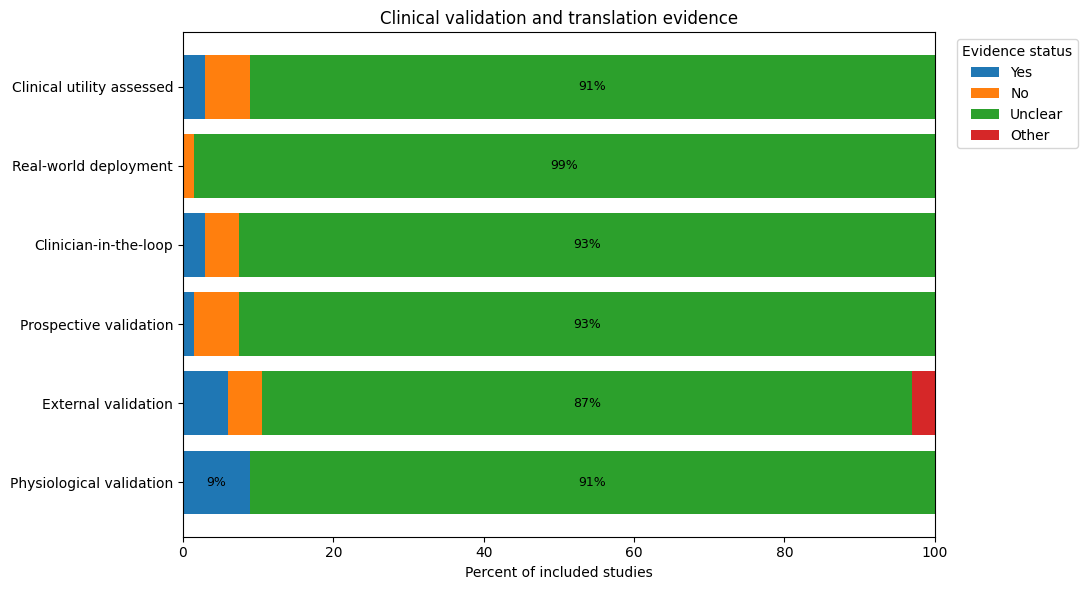

In [ ]:
translation_vars = {
    "Physiological_Validation":"Physiological validation",
    "External_Validation":"External validation",
    "Prospective_Validation":"Prospective validation",
    "Clinician_in_Loop":"Clinician-in-the-loop",
    "Real_World_Deployment":"Real-world deployment",
    "Clinical_Utility_Assessed":"Clinical utility assessed",
}

rows = []
for col, label in translation_vars.items():
    s = clean_status(focused[col])
    # Values outside Y/N/U are treated as Other and reported, not silently recoded.
    row = {"domain":label}
    for status in ["Yes","No","Unclear"]:
        row[status] = int((s==status).sum())
    row["Other"] = int((~s.isin(["Yes","No","Unclear"])).sum())
    row["Yes_percent"] = round(row["Yes"]/FOCUSED_N*100,1)
    rows.append(row)

translation = pd.DataFrame(rows)
save_table(translation, "06_clinical_translation_domains")
display(translation)

plot = translation.copy()
for status in ["Yes","No","Unclear","Other"]:
    plot[f"{status}_pct"] = plot[status]/FOCUSED_N*100

fig, ax = plt.subplots(figsize=(11,6))
left = np.zeros(len(plot))
for status in ["Yes","No","Unclear","Other"]:
    vals = plot[f"{status}_pct"].to_numpy()
    ax.barh(plot["domain"], vals, left=left, label=status)
    for i,v in enumerate(vals):
        if v >= 8:
            ax.text(left[i]+v/2, i, f"{v:.0f}%", ha="center", va="center", fontsize=9)
    left += vals

ax.set_xlim(0,100)
ax.set_xlabel("Percent of included studies")
ax.set_ylabel("")
ax.set_title("Clinical validation and translation evidence")
ax.legend(title="Evidence status", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGDIR/"06_translation_100pct_stacked.png", dpi=300, bbox_inches="tight")
plt.show()


# Domain D — Relationship between methods and clinical validation

## 9. XAI method × clinician-validation matrix

A heatmap is used because this is a cross-tabulation. Statistical testing is restricted to methods with enough observations.


Clinician_validation,Yes,No,Unclear
XAI_method,,,
Attention,0,3,4
CAM,0,1,1
Grad-CAM,1,18,11
Integrated Gradients,0,1,0
LIME,0,6,1
Occlusion,1,0,1
SHAP,2,21,12
Saliency map,1,1,0


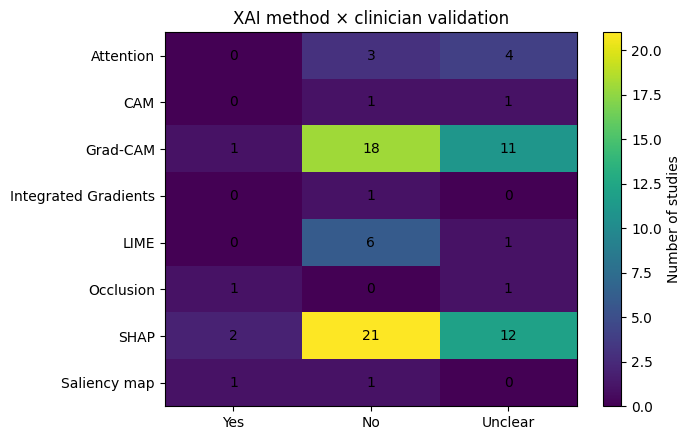

Saved: ecg_xai_scientific_outputs/07b_xai_clinician_fisher_tests.csv


,XAI_method,validated_yes_method,validated_no_method,validated_yes_other,validated_no_other,odds_ratio,fisher_p
0,SHAP,2,21,2,20,0.952381,1.000000
1,Grad-CAM,1,18,3,23,0.425926,0.627001
2,Attention,0,3,4,38,0.000000,1.000000
3,LIME,0,6,4,35,0.000000,1.000000


In [ ]:
long_rows = []
for i, methods in enumerate(xai_lists):
    status = clin.iloc[i]
    for method in methods:
        long_rows.append({"XAI_method":method, "Clinician_validation":status})

xai_clin_long = pd.DataFrame(long_rows)
xai_clin_matrix = pd.crosstab(xai_clin_long["XAI_method"], xai_clin_long["Clinician_validation"])
xai_clin_matrix = xai_clin_matrix.reindex(columns=["Yes","No","Unclear"], fill_value=0)
xai_clin_matrix.to_csv(OUTDIR/"07_xai_by_clinician_validation_matrix.csv")

display(xai_clin_matrix)

fig, ax = plt.subplots(figsize=(7, max(4.5,.55*len(xai_clin_matrix))))
im = ax.imshow(xai_clin_matrix.values, aspect="auto")
ax.set_xticks(range(len(xai_clin_matrix.columns)))
ax.set_xticklabels(xai_clin_matrix.columns)
ax.set_yticks(range(len(xai_clin_matrix.index)))
ax.set_yticklabels(xai_clin_matrix.index)
for i in range(xai_clin_matrix.shape[0]):
    for j in range(xai_clin_matrix.shape[1]):
        ax.text(j,i,int(xai_clin_matrix.iloc[i,j]),ha="center",va="center")
ax.set_title("XAI method × clinician validation")
fig.colorbar(im, ax=ax, label="Number of studies")
plt.tight_layout()
plt.savefig(FIGDIR/"07_xai_clinician_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Exploratory association test:
# Compare each sufficiently common XAI method vs all other studies for clinician validation,
# using determinate Yes/No only. Fisher's exact test is used for sparse 2x2 tables.
test_rows = []
if SCIPY_AVAILABLE:
    determinate = focused[clin.isin(["Yes","No"])].copy().reset_index(drop=True)
    determ_status = clin[clin.isin(["Yes","No"])].reset_index(drop=True)

    # reconstruct method presence for determinate rows
    determ_xai = split_multivalue(determinate["XAI_Method"])
    common_methods = [m for m,n in xai_counter.items() if n >= 5]

    for method in common_methods:
        present = pd.Series([method in vals for vals in determ_xai])
        a = int((present & determ_status.eq("Yes")).sum())
        b = int((present & determ_status.eq("No")).sum())
        c = int((~present & determ_status.eq("Yes")).sum())
        d = int((~present & determ_status.eq("No")).sum())

        table = [[a,b],[c,d]]
        odds, p = fisher_exact(table, alternative="two-sided")
        test_rows.append({
            "XAI_method":method, "validated_yes_method":a, "validated_no_method":b,
            "validated_yes_other":c, "validated_no_other":d,
            "odds_ratio":odds, "fisher_p":p
        })

xai_fisher = pd.DataFrame(test_rows)
if len(xai_fisher):
    save_table(xai_fisher, "07b_xai_clinician_fisher_tests")
    display(xai_fisher)
else:
    print("No inferential test run: insufficient determinate data or scipy unavailable.")


## 10. Architecture × clinician validation

A heatmap summarizes the pattern. Inferential tests are not forced when architecture categories are sparse.


Clinician_XAI_Validation,Yes,No,Unclear
DL_Architecture_Family,,,
CNN,3,16,8
CNN + Autoencoder,0,1,0
CNN + DNN/MLP,0,2,0
CNN + GRU,0,1,0
CNN + LSTM,0,3,3
CNN + LSTM + DNN/MLP,0,1,0
CNN + LSTM + ResNet,0,1,0
CNN + LSTM + Transformer,0,1,0
CNN + LSTM + Transformer + ResNet,0,1,0


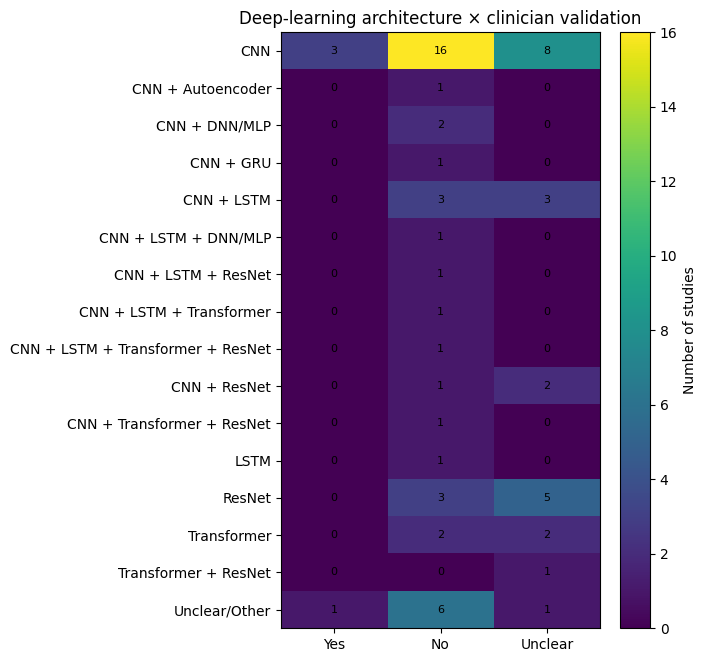

In [ ]:
arch_clin = pd.crosstab(
    focused["DL_Architecture_Family"].replace("", "Unclear/Other"),
    clin
)
arch_clin = arch_clin.reindex(columns=["Yes","No","Unclear"], fill_value=0)
arch_clin.to_csv(OUTDIR/"08_architecture_by_clinician_validation.csv")

display(arch_clin)

fig, ax = plt.subplots(figsize=(7, max(6,.42*len(arch_clin))))
im = ax.imshow(arch_clin.values, aspect="auto")
ax.set_xticks(range(len(arch_clin.columns)))
ax.set_xticklabels(arch_clin.columns)
ax.set_yticks(range(len(arch_clin.index)))
ax.set_yticklabels(arch_clin.index)
for i in range(arch_clin.shape[0]):
    for j in range(arch_clin.shape[1]):
        ax.text(j,i,int(arch_clin.iloc[i,j]),ha="center",va="center",fontsize=8)
ax.set_title("Deep-learning architecture × clinician validation")
fig.colorbar(im, ax=ax, label="Number of studies")
plt.tight_layout()
plt.savefig(FIGDIR/"08_architecture_clinician_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Architecture × XAI pairing

This heatmap characterizes methodological coupling between model architecture and explanation technique.


XAI_method,Attention,CAM,Grad-CAM,Integrated Gradients,LIME,Occlusion,SHAP,Saliency map
architecture,,,,,,,,
CNN,3,1,10,0,1,1,15,2
CNN + Autoencoder,0,0,1,0,0,0,0,0
CNN + DNN/MLP,0,0,1,0,1,0,1,0
CNN + GRU,0,0,0,0,1,0,0,0
CNN + LSTM,1,0,2,0,0,0,5,0
CNN + LSTM + DNN/MLP,0,0,1,0,0,0,0,0
CNN + LSTM + ResNet,0,0,0,0,1,0,1,0
CNN + LSTM + Transformer,0,0,0,0,0,0,1,0
CNN + LSTM + Transformer + ResNet,0,0,1,0,0,0,0,0


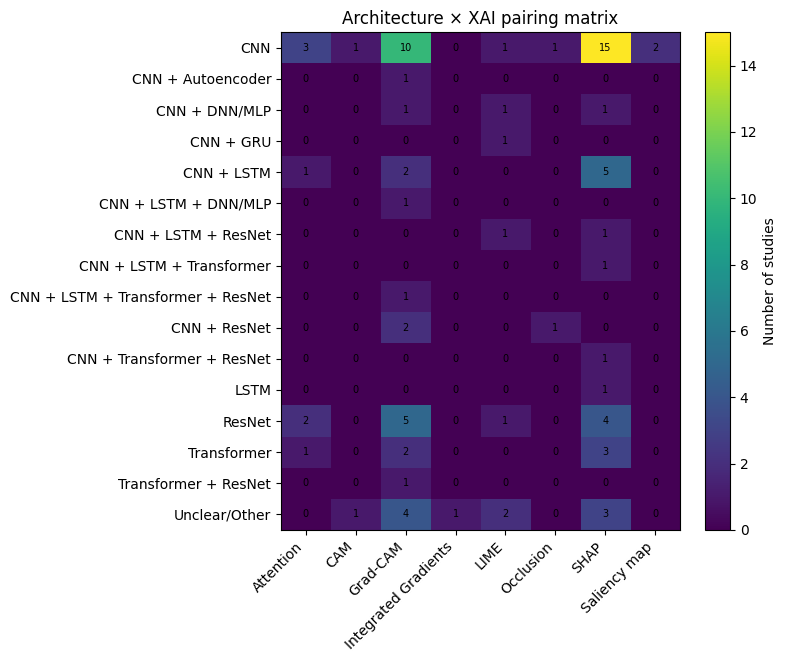

In [ ]:
pair_rows = []
for i, methods in enumerate(xai_lists):
    arch = focused.loc[i,"DL_Architecture_Family"] or "Unclear/Other"
    for method in methods:
        pair_rows.append({"architecture":arch,"XAI_method":method})

pair_long = pd.DataFrame(pair_rows)
pair_matrix = pd.crosstab(pair_long["architecture"], pair_long["XAI_method"])
pair_matrix.to_csv(OUTDIR/"09_architecture_xai_matrix.csv")

display(pair_matrix)

fig, ax = plt.subplots(figsize=(max(8,.8*pair_matrix.shape[1]), max(6,.42*pair_matrix.shape[0])))
im = ax.imshow(pair_matrix.values, aspect="auto")
ax.set_xticks(range(pair_matrix.shape[1]))
ax.set_xticklabels(pair_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(pair_matrix.shape[0]))
ax.set_yticklabels(pair_matrix.index)
for i in range(pair_matrix.shape[0]):
    for j in range(pair_matrix.shape[1]):
        ax.text(j,i,int(pair_matrix.iloc[i,j]),ha="center",va="center",fontsize=7)
ax.set_title("Architecture × XAI pairing matrix")
fig.colorbar(im, ax=ax, label="Number of studies")
plt.tight_layout()
plt.savefig(FIGDIR/"09_architecture_xai_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# Domain E — Dataset and predictive-performance evidence

## 12. Dataset use

The full frequency table is primary. A dot plot is shown only for the most frequent dataset labels.


Saved: ecg_xai_scientific_outputs/10_dataset_counts.csv


,dataset,n,percent_of_studies
0,MIT-BIH Arrhythmia Database,6,9.0
1,80% training and 20% testing,2,3.0
2,PTB-XL dataset,1,1.5
3,Arrhythmia dataset,1,1.5
4,"PTB-XL, CODE-15%, Chapman Arrhythmia",1,1.5
5,ECG dataset,1,1.5
6,MIT-BIH Arrhythmia dataset,1,1.5
7,MIT-BIH Arrhythmia (primary)\n+ AHA + LUDB (external validation),1,1.5
8,MIT-BIH SCD Holter + MIT-BIH Normal Sinus Rhythm,1,1.5
9,Long-Term Atrial Fibrillation (LTAF) Database,1,1.5


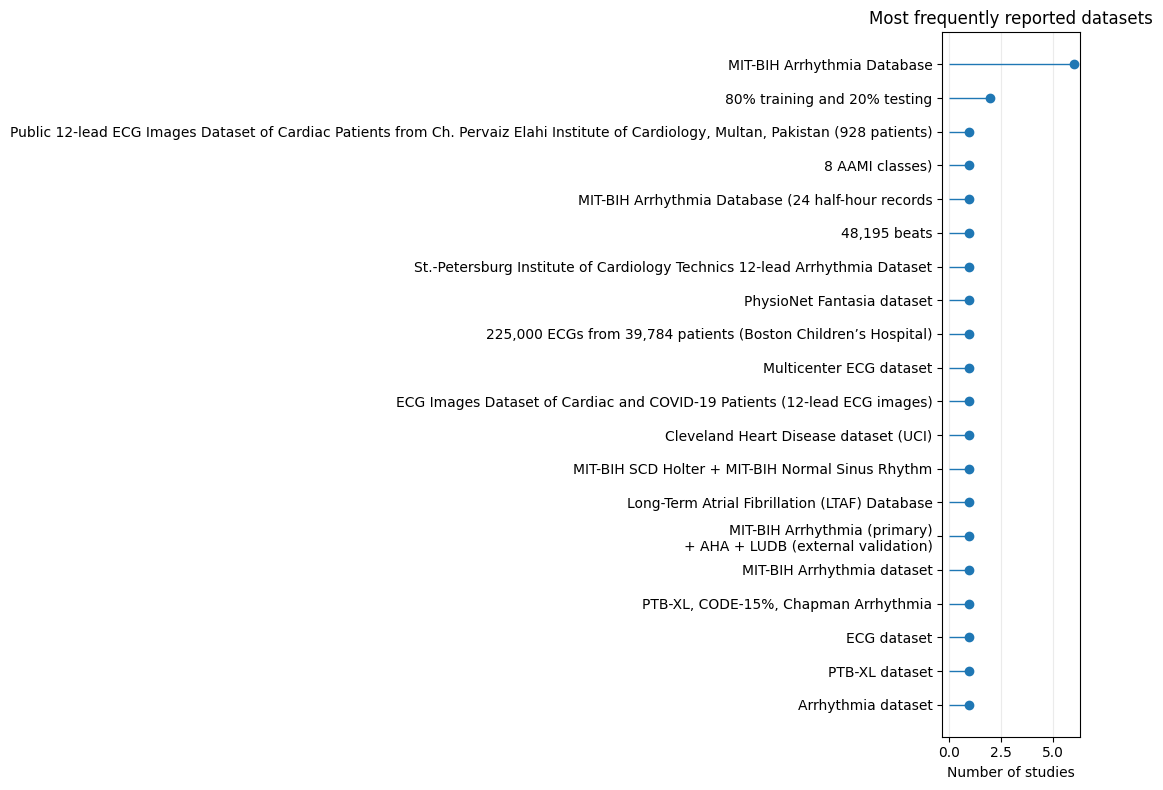

In [ ]:
dataset_lists = split_multivalue(focused["Dataset"])
dataset_counter = Counter(x for vals in dataset_lists for x in vals)

dataset_counts = pd.DataFrame(dataset_counter.most_common(), columns=["dataset","n"])
dataset_counts["percent_of_studies"] = (dataset_counts["n"]/FOCUSED_N*100).round(1)
save_table(dataset_counts, "10_dataset_counts")

display(dataset_counts.head(30))

top = dataset_counts.head(20).sort_values("n")
fig, ax = plt.subplots(figsize=(11,8))
ax.hlines(top["dataset"], 0, top["n"], linewidth=1)
ax.plot(top["n"], top["dataset"], "o")
ax.set_xlabel("Number of studies")
ax.set_ylabel("")
ax.set_title("Most frequently reported datasets")
ax.grid(axis="x", alpha=.25)
plt.tight_layout()
plt.savefig(FIGDIR/"10_dataset_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Predictive-performance metrics

Only values that can be extracted consistently from the coded performance field are summarized. Because tasks and datasets are heterogeneous, the analysis remains descriptive.

A boxplot is shown only for metrics with at least 5 extractable values.


Saved: ecg_xai_scientific_outputs/11_performance_metric_summary.csv


,metric,n_extractable,median,IQR_Q1,IQR_Q3,min,max
0,Accuracy,39,97.00,93.60,98.76,75.98,100.00
1,AUC/AUROC,21,93.41,84.00,98.00,52.00,100.00
2,F1-score,19,92.00,86.69,96.85,78.90,98.97
3,Sensitivity/Recall,16,95.00,89.10,97.44,77.50,99.80
4,Specificity,7,96.00,74.40,97.13,72.86,99.90


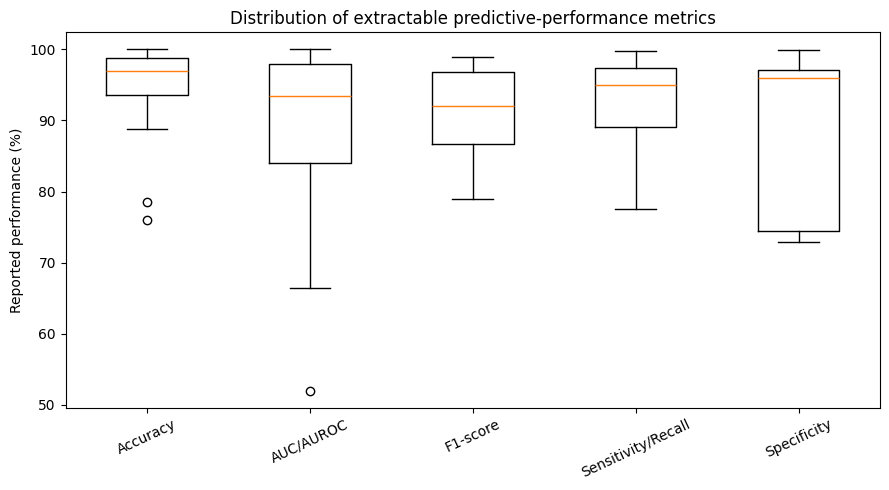

In [ ]:
metric_text = focused["Performance_Metrics_Raw"].fillna("").astype(str)

metric_patterns = {
    "Accuracy": r"(?:accuracy|acc)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*%?",
    "AUC/AUROC": r"(?:auc|auroc)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*%?",
    "F1-score": r"(?:f1[- ]?score|f1)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*%?",
    "Sensitivity/Recall": r"(?:sensitivity|recall)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*%?",
    "Specificity": r"(?:specificity)\s*[:=]?\s*(\d+(?:\.\d+)?)\s*%?",
}

metric_values = {}
summary_rows = []

for metric, pat in metric_patterns.items():
    vals = pd.to_numeric(metric_text.str.extract(pat, flags=re.I)[0], errors="coerce")
    vals.loc[vals.between(0,1,inclusive="both")] *= 100
    metric_values[metric] = vals.dropna()

    v = metric_values[metric]
    summary_rows.append({
        "metric":metric, "n_extractable":len(v),
        "median":round(v.median(),2) if len(v) else np.nan,
        "IQR_Q1":round(v.quantile(.25),2) if len(v) else np.nan,
        "IQR_Q3":round(v.quantile(.75),2) if len(v) else np.nan,
        "min":round(v.min(),2) if len(v) else np.nan,
        "max":round(v.max(),2) if len(v) else np.nan,
    })

performance_summary = pd.DataFrame(summary_rows)
save_table(performance_summary, "11_performance_metric_summary")
display(performance_summary)

plot_metrics = [m for m,v in metric_values.items() if len(v) >= 5]
if plot_metrics:
    vals = [metric_values[m].to_numpy() for m in plot_metrics]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.boxplot(vals, tick_labels=plot_metrics, showfliers=True)
    ax.set_ylabel("Reported performance (%)")
    ax.set_title("Distribution of extractable predictive-performance metrics")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(FIGDIR/"11_performance_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No performance metric had at least five consistently extractable values.")


# Domain F — Evidence-gap analysis

## 14. Positive evidence with 95% confidence intervals

For each translation domain, the proportion of included studies with **positive evidence (`Yes`)** is shown with a Wilson 95% confidence interval.

This is a descriptive uncertainty interval for the observed review corpus; it is not a population causal estimate.


Saved: ecg_xai_scientific_outputs/12_clinical_evidence_proportions.csv


,domain,Yes_n,Yes_percent,CI_low_percent,CI_high_percent,No_n,Unclear_n
5,Real-world deployment,0,0.000000,0.000000,5.422802,1,66
3,Prospective validation,1,1.492537,0.263950,7.982052,4,62
4,Clinician-in-the-loop,2,2.985075,0.822452,10.246750,3,62
6,Clinical utility assessed,2,2.985075,0.822452,10.246750,4,61
0,Clinician XAI validation,4,5.970149,2.345897,14.369705,41,22
2,External validation,4,5.970149,2.345897,14.369705,3,58
1,Physiological validation,6,8.955224,4.169038,18.192964,0,61


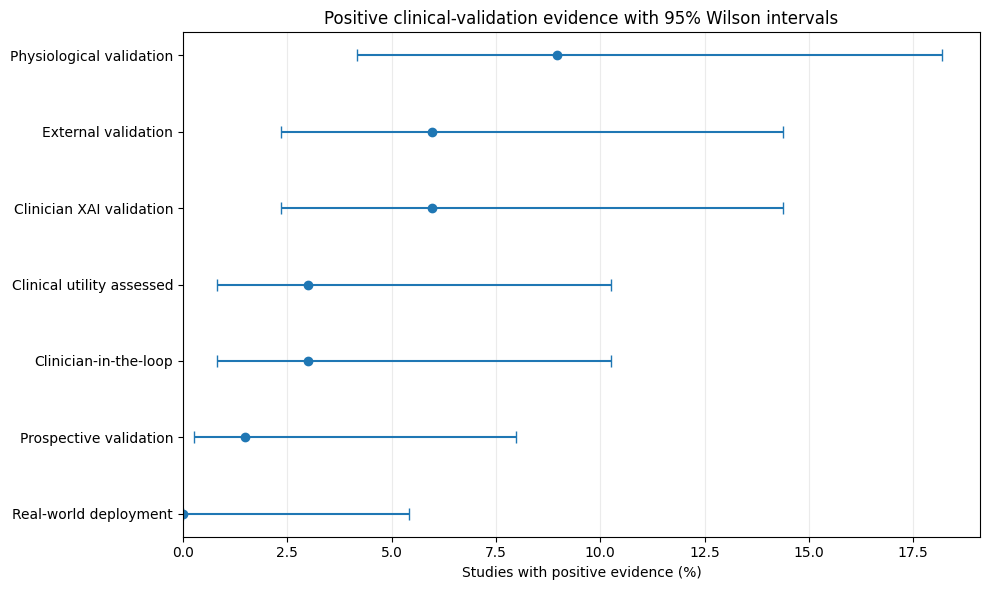

In [ ]:
gap_domains = {
    "Clinician_XAI_Validation":"Clinician XAI validation",
    "Physiological_Validation":"Physiological validation",
    "External_Validation":"External validation",
    "Prospective_Validation":"Prospective validation",
    "Clinician_in_Loop":"Clinician-in-the-loop",
    "Real_World_Deployment":"Real-world deployment",
    "Clinical_Utility_Assessed":"Clinical utility assessed",
}

gap_rows = []
for col,label in gap_domains.items():
    s = clean_status(focused[col])
    k = int((s=="Yes").sum())
    lo,hi = wilson_ci(k, FOCUSED_N)
    gap_rows.append({
        "domain":label, "Yes_n":k,
        "Yes_percent":100*k/FOCUSED_N if FOCUSED_N else np.nan,
        "CI_low_percent":100*lo,
        "CI_high_percent":100*hi,
        "No_n":int((s=="No").sum()),
        "Unclear_n":int((s=="Unclear").sum())
    })

gap = pd.DataFrame(gap_rows).sort_values("Yes_percent")
save_table(gap, "12_clinical_evidence_proportions")
display(gap)

fig, ax = plt.subplots(figsize=(10,6))
x = gap["Yes_percent"].to_numpy()
lower = x-gap["CI_low_percent"].to_numpy()
upper = gap["CI_high_percent"].to_numpy()-x
ax.errorbar(x, gap["domain"], xerr=[lower,upper], fmt="o", capsize=4)
ax.set_xlabel("Studies with positive evidence (%)")
ax.set_ylabel("")
ax.set_title("Positive clinical-validation evidence with 95% Wilson intervals")
ax.set_xlim(left=0)
ax.grid(axis="x", alpha=.25)
plt.tight_layout()
plt.savefig(FIGDIR/"12_evidence_gap_interval_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# 15. Thesis-ready results summary

This cell generates descriptive statements only. It does not claim statistical significance unless an explicit test above supports it.


In [ ]:
headline = pd.DataFrame([
    ["Master PRISMA records", len(data), ""],
    ["Focused included studies", FOCUSED_N, ""],
    ["Most frequent XAI method", int(xai_counts.iloc[0]["n"]) if len(xai_counts) else 0, xai_counts.iloc[0]["XAI_method"] if len(xai_counts) else ""],
    ["Most frequent architecture", int(arch_counts.iloc[0]["n"]) if len(arch_counts) else 0, arch_counts.iloc[0]["architecture"] if len(arch_counts) else ""],
    ["Clinician-validated XAI", int((clin=="Yes").sum()), f"{(clin=='Yes').mean()*100:.1f}%"],
    ["Prospective validation", int((clean_status(focused['Prospective_Validation'])=='Yes').sum()), f"{(clean_status(focused['Prospective_Validation'])=='Yes').mean()*100:.1f}%"],
    ["Clinician-in-the-loop", int((clean_status(focused['Clinician_in_Loop'])=='Yes').sum()), f"{(clean_status(focused['Clinician_in_Loop'])=='Yes').mean()*100:.1f}%"],
    ["Real-world deployment", int((clean_status(focused['Real_World_Deployment'])=='Yes').sum()), f"{(clean_status(focused['Real_World_Deployment'])=='Yes').mean()*100:.1f}%"],
], columns=["finding","n","detail"])

save_table(headline, "13_headline_findings")
display(headline)


Saved: ecg_xai_scientific_outputs/13_headline_findings.csv


,finding,n,detail
0,Master PRISMA records,232,
1,Focused included studies,67,
2,Most frequent XAI method,35,SHAP
3,Most frequent architecture,27,CNN
4,Clinician-validated XAI,4,6.0%
5,Prospective validation,1,1.5%
6,Clinician-in-the-loop,2,3.0%
7,Real-world deployment,0,0.0%


# 16. Export all outputs

The ZIP contains all tables and scientifically matched figures.


In [ ]:
focused.to_csv(OUTDIR/"14_focused_analysed_studies.csv", index=False)
data.to_csv(OUTDIR/"15_master_232_audit_dataset.csv", index=False)

zip_path = Path("ecg_xai_scientific_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUTDIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(OUTDIR)))

print("Created:", zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    pass


Created: ecg_xai_scientific_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>